<span style="font-size:11px">

##### ▶ DNN CNN
- 독립적인 정보
- 입력(x) 간의 순서나 연관성을 고려하지 않음

##### ▶ 시계열 : 시간의 연속적인 흐름
- 시계열 데이터 : 날씨, 주식, 문장 ---> 순서가 중요한 데이터

##### ▶ RNN (Recurrent Neural Network)
- 순환하는 구조
    - 시점1 (월요일) : 맑음(x1) 정보가 RNN에 들어온다 --> RNN날씨가 맑았음(h1) 이라는 요약본을 생성
    - 시점2 (화요일) : 흐림(x2) --> RNN 새로운 정보(흐림,x2) + 어제의기억(맑았음, h1) 함께 고려해서 
                      어제는 맑았는데 오늘은 흐림h2 라는 새로운 요약본을 생성
    - 시점3 (수요일) : 비(x3) --> RNN 새로운정보(비,x3) 정보와 어제의기억 (어제는 맑았는데 오늘은 흐림 h2)과 함께 새로운 상태 h3라는 요약본을 생성
    - 반복
- 알고리즘
    - 각 시점(time step)에서 1현재의 입력과 2과거의 기억(hidden state h_t-1)을 받아서 3현재의 결과물과 4다음시점으로 넘겨줄 최신기억 h_t를 생성
    - h_t기억이 시계열 데이터의 맥락(Context) 저장하는 역할
- 장점
    - 순서가 있는 데이터의 맥락을 학습
- 한계
    - 기억력이 생각보다 짧음
    - 시계열 데이터가 길어지면(ex. 100단계 전의 정보), 이전정보가 소실되거나 반대로 너무 강해져서 폭주가 되서 제대로 학습이 안됨
    - 장기 기억 의존성 문제가 발생 (Long-Term Dependency Problem)

##### ▶ LSTM & GRU : RNN에서는 LSTM보다 GRU를 더 사용함
- LSTM (Long Short-Term Memory) :
    - RNN의 단점(기울기 소실)을 해결하기 위해 '셀 상태(cell state)'와 게이트 구조를 도입
    - RNN 내부에 게이트(Gate) 장치(복잡한 장치) --> 잊고 기억할 정보를 관리

- GRU (Gated Recurrent Unit) : 
    - 셀 상태(cell state) 없이, update gate와 reset gate 2개만 사용.
    - LSTM구조를 단순화 시킨 모델, LSTM과 성능은 비슷하나 속도는 더 빠름, 메모리 사용량도 작음

##### RNN 핵심수식
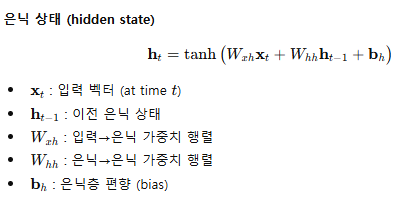

- x_t : 시점 t의 입력(특성 벡터) — 이 값의 크기가 input_size
- h_t : 숨겨진 상태(hidden state) — 크기 hidden_size


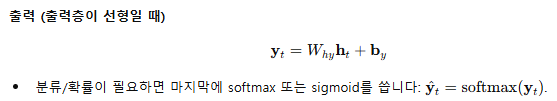


| 항목       | RNN             | LSTM                       | GRU                |
| -------- | --------------- | -------------------------- | ------------------ |
| 기억 구조    | 단일 hidden state | cell state + hidden state  | 단일 hidden state    |
| 게이트 수    | 없음              | 3개 (Forget, Input, Output) | 2개 (Update, Reset) |
| 장기 기억 유지 | 약함              | 강함                         | 강함                 |
| 계산 속도    | 빠름              | 느림                         | 중간                 |
| 파라미터 수   | 적음              | 많음                         | 중간                 |
| 대표 사용처   | 간단한 시계열         | 자연어처리, 번역                  | 빠른 학습, 성능 타협형      |


In [1]:
import pandas as pd
url = 'https://raw.githubusercontent.com/pia222sk20/python/refs/heads/main/data/time_data_train.csv'
df = pd.read_csv(url)
df.head()

,Date,Open,High,Low,Volume,Close
0,2015-12-16,120,123,118,13181000,123
1,2015-12-17,124,126,122,17284900,123
2,2015-12-18,121,122,118,17948100,118
3,2015-12-21,120,120,116,11670000,117
4,2015-12-22,117,117,115,9689000,116


In [2]:
# 전체 데이터셋 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    967 non-null    object
 1   Open    967 non-null    int64 
 2   High    967 non-null    int64 
 3   Low     967 non-null    int64 
 4   Volume  967 non-null    int64 
 5   Close   967 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 45.5+ KB


In [3]:
# EDA - 탐색적 데이터 분석

In [28]:
######## 실행1
# 데이터셋 정의
import numpy as np
from torch.utils.data.dataset import Dataset
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch

class StockDataSet (Dataset):
    def __init__(self):
        url = 'https://raw.githubusercontent.com/pia222sk20/python/refs/heads/main/data/time_data_train.csv'
        self.csv = pd.read_csv(url)
        data = self.csv.iloc[:, 1:-1].values # 첫 열(보통 날짜 등)을 제외하고 마지막 열(정답)을 제외한 모든 컬럼을 feature로 사용.
        label = self.csv.iloc[:,-1].values.reshape(-1,1) #reshape 2차원으로 변경

        # 정답의 숫자가 크다면 정규화가 학습에 도움이됨
        # 이후 결과값을 다시 원래수치로 돌리기 위해서 정규화 따로 정의함
        self.data_scaler = StandardScaler()
        self.label_scaler = StandardScaler()
        self.data = self.data_scaler.fit_transform(data)
        self.label = self.label_scaler.fit_transform(label)

        # torch.Tensor :  array에서 tensor로 변경됨을 확인 (순서 중요. 정규화전에 하면 최종 array로 되므로 정규화 이후에 tensor)
        self.data = torch.Tensor(self.data)
        self.label = torch.Tensor(self.label)
    

    # 시계열 슬라이딩 윈도우 : 시계열 예측용 데이터셋을 만드는 핵심
    # 시계열 모델은 이전 30일 데이터를 묶어서 하나의 샘플로 사용
    def __len__(self):
        return len(self.data) - 30 #len(data) - window_size 
    def __getitem__(self, index):

        # data.shape = (30, feature_dim) — 30 타임스텝(시퀀스 길이)
        # label.shape = (1,) 또는 (1,1)
        data = self.data[index : index + 30]
        label = self.label[index+30]
        return data, label
     

In [5]:
sample_data, sample_label = next(iter(StockDataSet()))
sample_data.size(), sample_label.size() 

(torch.Size([30, 4]), torch.Size([1]))

In [6]:
# 상기 self.csv.iloc[:,-1].values 오류 확인
df.iloc[:, 1:-1].values
df.iloc[:, 1:-1].values.shape, df.iloc[:,-1].values.shape 

((967, 4), (967,))

In [7]:
# 상기 함수 작동여부 확인
# self.csv.iloc[:,-1].values.reshape(-1,1) 변경 후 오류없음
# torch.Tensor :  array에서 tensor로 변경됨을 확인 (순서 중요. 정규화전에 하면 최종 array로 되므로 정규화 이후에 tensor)

dataset = StockDataSet()
sample_data, sample_label = next(iter(dataset))
sample_data, sample_label
sample_data.shape

torch.Size([30, 4])

In [8]:
######## 실행2

import torch.nn as nn
class StockRNN(nn.Module):
    def __init__ (self):
        super(StockRNN,self).__init__()

        # input 상기 출력물에서 컬럼(세로열) / 속성의 갯수 --> 4
        # sample_data.shape은 (30, 4) 입니다. 
        # 30 → 시퀀스 길이 (즉, 30일치 과거 데이터) / 4 → 각 시점의 feature(입력 변수) 수

        # RNN 입력 텐서 형태 (seq_len=30, batch_size, input_size=4) -- 기본값 batch_first=False
        # batch_first = True (FC(MLP), CNN 연결할때 편리) --> (batch_size, seq_len=30, input_size=4)
       
        # num_layer : RNN 레이어 길이 
        self.rnn = nn.RNN(input_size=4, hidden_size=8, num_layers=5, batch_first=True)   

        # fc층 : 상기 rnn 최종 출력 ??? (batch, 30, 8) 30일치 데이터*hidden_size ??
        self.fc1 = nn.Linear (30*8, 64)
        self.fc2 = nn.Linear (64, 1)
        self.relu = nn.ReLU()

    def forward (self,x,ho): 
        # batch_first=True → forward에 들어오는 x는 (batch_size=16, seq_len=30, input_size=4) 형태
            # 입력데이터는 (16,30,4) 배치16, 30일씩 묶음, 특성4
                # ↓
        # ho : 초기 은닉상태 (num_layers=5, batch_size=16, hidden_size=8) (5,16,8) -- RNN은 hidden state를 "이전상태"로 받아서 계산하므로 초기 ho가 필요
                # ↓
        # 출력 x는 모든 시점에 대한 은닉층들의 출력을 담고 있음 (모든 타임스탬프의 hidden state출력) -- ex. 모든날씨 요약본(h1+h2+h3) 전체를 담고있음
            # (hidden output) : (batch_size, seq_len, hidden_size) --> (16,30,8)

        # 출력 hn은 최종은닉상태 (각 레이어의 마지막 타임스탬프 hidden state) 
            # (num_layer, batch_size, hidden_state) --> (5,16,8)

        x, hn = self.rnn(x,ho) 
        # x : 시퀀스 모든 시점의 hidden state를 담고 있어서, 예를 들어 30일 데이터를 MLP로 보내서 전체 패턴을 학습할 때 필요
        # hn : 마지막 시점의 hidden state만 담고 있어서, 예를 들어 “내일 날씨 예측”처럼 “마지막 상태만 중요할 때” 사용
        # “30일 전체 데이터로 예측” → x 사용
        # “마지막 상태로 예측” → hn 사용




        # mlp (FC층) 입력으로 사용될 수 있도록 모양 변경
        # RNN을 통과한 후 출력 : x.shape = (batch_size, seq_len, hidden_size)
        # nn.Linear(FC층)는 2D 입력만 받음 (batch_size, features)
        # 시계열 축(seq_len)과 hidden 축(hidden_size)을 하나로 합쳐서 2차원 (16, 30, 8) → (16, 30*8) 
        x = torch.reshape(x, (x.shape[0],-1)) 
        # reshape(x, (x.shape[0],-1)) “x의 모양을 (x.shape[0], -1)로 바꿔줘”
        #x.shape[0]=batch_size=16 , -1: pytorch가 알아서 남은 차원의 크기를 계산
        
        # mlp
        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        # 예측한 최종 1차원 벡터
        out = torch.flatten(x)
        return out




In [9]:
rnn = StockRNN()
sample_data=torch.randn(16,30,4) #배치16, 30일씩 묶음, 특성4
# sample_data

# 초기 hidden state 값 줘야함. (num_layer, batch_size, hidden_size) --> (5, 16, 8)
ho = torch.zeros (5,16,8)
out = rnn(sample_data, ho)
out
out.size()

torch.Size([16])

In [10]:
######## 실행3
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader
device= 'cuda' if torch.cuda.is_available() else 'cpu'
model = StockRNN().to(device)
dataset = StockDataSet()
loader = DataLoader(dataset, batch_size=16)
optim = Adam(model.parameters(), lr=1e-3)

In [11]:
# pred = model() 확인을 위해.. 
data, label = next(iter(loader))
data.dtype, label.dtype

(torch.float32, torch.float32)

In [12]:
######## 실행4
# 학습루프
from tqdm import tqdm

# criterian = nn.MSELoss()
model.train()
for epoch in range(200):
    loop = tqdm(loader)
    for data, label in loop:
        optim.zero_grad()
        # 초기 은닉상태
        # 초기 은닉상태의 배치크기는 DataLoader가 주는 배치 크기
        batch_size = data.size(0)
        ho = torch.zeros(5,batch_size,8).to(device)   
        # (5,16,8) ---> (5,batch_size,8) / 데이터에 따라 배치를 묶으면 마지막에 데이터가 1개 남으면 마지막 배치사이즈는 1이될수도 있으므로. 고정하지말것.
        
        
        # 모델의 예측값
        pred = model(data.to(device), ho)
        # 손실값
        loss = nn.MSELoss()(pred, label.to(device)) #nn.MSELoss()객체이므로, () 기재하지말것 / loss = criterian(여기쓰므로) 헷갈리지마
        loss.backward()
        optim.step()

        loop.set_description(f'epoch:{epoch+1}, loss:{loss.item()}')

torch.save(model.state_dict(), './rnn.pth')



  0%|          | 0/59 [00:00<?, ?it/s]c:\Users\playdata2\miniconda3\envs\deep\Lib\site-packages\torch\nn\modules\loss.py:538: UserWarning: Using a target size (torch.Size([16, 1])) that is different to the input size (torch.Size([16])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
epoch:1, loss:0.9124589562416077:  90%|████████▉ | 53/59 [00:01<00:00, 63.99it/s]  c:\Users\playdata2\miniconda3\envs\deep\Lib\site-packages\torch\nn\modules\loss.py:538: UserWarning: Using a target size (torch.Size([9, 1])) that is different to the input size (torch.Size([9])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
epoch:200, loss:0.0072592636570334435: 100%|██████████| 59/59 [00:01<00:00, 53.37it/s]


In [13]:
### 오류 발생 RuntimeError: Expected hidden size (5, 9, 8), got [5, 16, 8]
# Rnn이 처리하는 배치크기는 9, 우리가 설계한 ho는 16
# 마지막 배치 갯수가 부족해서 9로 나옴..??
len(dataset) % 16

9

In [14]:
######## 실행5
# 모델 성능평가하기
import matplotlib.pyplot as plt

model.eval()
loader = DataLoader(dataset, batch_size=1)
preds = []
total_loss = 0
with torch.no_grad() :
    model.load_state_dict(torch.load('rnn.pth', map_location=device, weights_only=False))
    for data, label in loader:
        # 초기 은닉상태의 배치크기는 DataLoader가 주는 배치 크기
        batch_size = data.size(0)
        ho = torch.zeros(5,batch_size,8).to(device)
        # 모델의 예측값
        pred = model(data.to(device), ho)
        preds.append(pred.item())
        # 손실값
        loss = nn.MSELoss()(pred, label.to(device))
        total_loss += (loss.item() / len(loader))

print (f'total_loss : {total_loss: .4f}')


c:\Users\playdata2\miniconda3\envs\deep\Lib\site-packages\torch\nn\modules\loss.py:538: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


total_loss :  0.0233


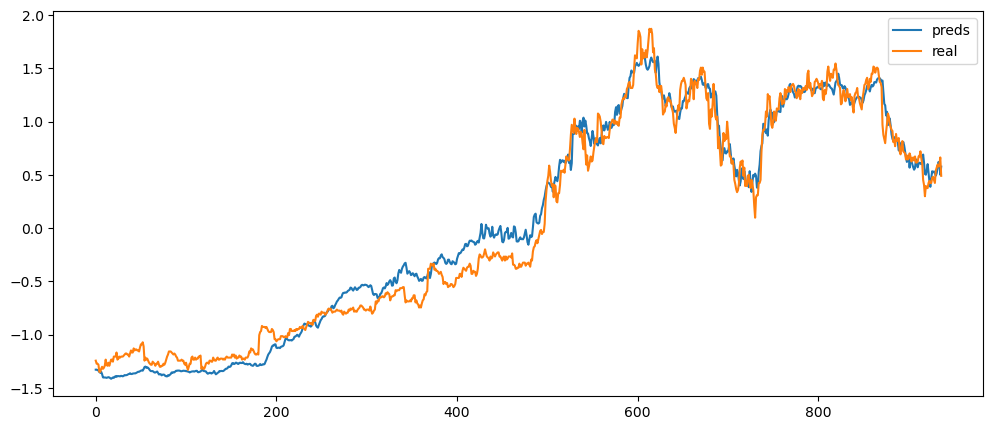

In [15]:
plt.figure(figsize=(12,5))
plt.plot(preds, label='preds')
plt.plot(dataset.label[30:], label='real')
plt.legend()
plt.show()

========================= 추가 확인 / 30일 뒤 예측 ===========

In [ ]:
# 마지막 시점 데이터를 입력으로 해서, 그 다음(미래 한 시점)**을 예측

with torch.no_grad():
    last_30 = df.iloc[-30:, 1:-1].values
    X = torch.tensor(last_30, dtype=torch.float32).unsqueeze(0)  #현재는 (34,4) 이렇게 나와서 ( , 34, 4)로 만들기 위해서 차수 늘려줌.
    # (num_layer, batch, hidden)
    ho = torch.zeros(5,1,8).to(device)
    pred = model(X.to(device),ho)
    pred_original = scaler.inverse_transform(pred.cpu().numpy().reshape(1,-1))  #정규화 됐었던 것을 원결과값으로 받기위해
    print(pred.item())

1.2286089658737183


In [17]:
# y finanace : 스케일화된 것을 다시 원값으로 조정

from sklearn.preprocessing import StandardScaler
X = np.array([
    [10,20],[100,200]
])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1., -1.],
       [ 1.,  1.]])

In [18]:
scaler.inverse_transform(X_scaled)

array([[ 10.,  20.],
       [100., 200.]])

=====================================================

In [19]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [20]:
import yfinance as yf
dat = yf.Ticker("TSLA")     #테슬라 주식코드 TSLA
dat.history(period = '1y')

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2024-10-29 00:00:00-04:00,264.510010,264.980011,255.509995,259.519989,80521800,0.0,0.0
2024-10-30 00:00:00-04:00,258.040009,263.350006,255.820007,257.549988,53993600,0.0,0.0
2024-10-31 00:00:00-04:00,257.989990,259.750000,249.250000,249.850006,66575300,0.0,0.0
2024-11-01 00:00:00-04:00,252.039993,254.000000,246.630005,248.979996,57544800,0.0,0.0
2024-11-04 00:00:00-05:00,244.559998,248.899994,238.880005,242.839996,68802400,0.0,0.0
...,...,...,...,...,...,...,...
2025-10-22 00:00:00-04:00,443.450012,445.540009,429.000000,438.970001,84023500,0.0,0.0
2025-10-23 00:00:00-04:00,420.000000,449.399994,413.899994,448.980011,126709800,0.0,0.0
2025-10-24 00:00:00-04:00,446.829987,451.679993,430.170013,433.720001,94727800,0.0,0.0


#### >>> yfinance 실습
- 독립변수 (X), 종속변수 (y) 분리
- window size : 30 (한달치 데이터를 하나의 dataset)
- 배치는 3배치
- 알고리즘은 RNN 

In [21]:

######## 실행1
# 데이터셋 정의
import numpy as np
from torch.utils.data.dataset import Dataset
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
import yfinance as yf



class StockDataSet (Dataset):
    def __init__(self):
        dat = yf.Ticker("TSLA")     #테슬라 주식코드 TSLA
        self.dat = dat.history(period = '1y')
        data = self.dat.loc[:, ['Open', 'High', 'Low', 'Volume']]
        label = self.dat.loc[:, ['Close']]

         # 정답의 숫자가 크다면 정규화가 학습에 도움이됨
        self.data = StandardScaler().fit_transform( data )
        self.label = StandardScaler().fit_transform( label ) 

        # torch.Tensor :  array에서 tensor로 변경됨을 확인 (순서 중요. 정규화전에 하면 최종 array로 되므로 정규화 이후에 tensor)
        self.data = torch.Tensor(self.data)
        self.label = torch.Tensor(self.label)
    

    # 시계열 슬라이딩 윈도우 : 시계열 예측용 데이터셋을 만드는 핵심
    # 시계열 모델은 이전 30일 데이터를 묶어서 하나의 샘플로 사용
    def __len__(self):
        return len(self.data) - 30 #len(data) - window_size 
    def __getitem__(self, index):

        # data.shape = (30, feature_dim) — 30 타임스텝(시퀀스 길이)
        # label.shape = (1,) 또는 (1,1)
        data = self.data[index : index + 30]
        label = self.label[index+30]
        return data, label
     

In [22]:
######## 실행2

import torch.nn as nn
class StockRNN(nn.Module):
    def __init__ (self):
        super(StockRNN,self).__init__()
        self.rnn = nn.RNN(input_size=4, hidden_size=8, num_layers=5, batch_first=True)   
        self.fc1 = nn.Linear (30*8, 64)
        self.fc2 = nn.Linear (64, 1)
        self.relu = nn.ReLU()

    def forward (self,x,ho): 

        x, hn = self.rnn(x,ho) 
        x = torch.reshape(x, (x.shape[0],-1)) 
 
        
        # mlp
        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        # 예측한 최종 1차원 벡터
        out = torch.flatten(x)
        return out

In [23]:
######## 실행3
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader
device= 'cuda' if torch.cuda.is_available() else 'cpu'
model = StockRNN().to(device)
dataset = StockDataSet()
loader = DataLoader(dataset, batch_size=3)
optim = Adam(model.parameters(), lr=1e-3)


######## 실행4
# 학습루프
from tqdm import tqdm

# criterian = nn.MSELoss()
model.train()
for epoch in range(200):
    loop = tqdm(loader)
    for data, label in loop:
        optim.zero_grad()
        # 초기 은닉상태
        # 초기 은닉상태의 배치크기는 DataLoader가 주는 배치 크기
        batch_size = data.size(0)
        ho = torch.zeros(5,batch_size,8).to(device)   
        # (5,16,8) ---> (5,batch_size,8) / 데이터에 따라 배치를 묶으면 마지막에 데이터가 1개 남으면 마지막 배치사이즈는 1이될수도 있으므로. 고정하지말것.
        
        
        # 모델의 예측값
        pred = model(data.to(device), ho)
        # 손실값
        loss = nn.MSELoss()(pred, label.to(device)) #nn.MSELoss()객체이므로, () 기재하지말것 / loss = criterian(여기쓰므로) 헷갈리지마
        loss.backward()
        optim.step()

        loop.set_description(f'epoch:{epoch+1}, loss:{loss.item()}')

torch.save(model.state_dict(), './rnn_TSLA.pth')



  0%|          | 0/74 [00:00<?, ?it/s]c:\Users\playdata2\miniconda3\envs\deep\Lib\site-packages\torch\nn\modules\loss.py:538: UserWarning: Using a target size (torch.Size([3, 1])) that is different to the input size (torch.Size([3])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
epoch:1, loss:2.2426226139068604:  93%|█████████▎| 69/74 [00:01<00:00, 58.56it/s]  c:\Users\playdata2\miniconda3\envs\deep\Lib\site-packages\torch\nn\modules\loss.py:538: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
epoch:200, loss:9.960918396245688e-05: 100%|██████████| 74/74 [00:01<00:00, 57.46it/s]


total_loss :  0.0796


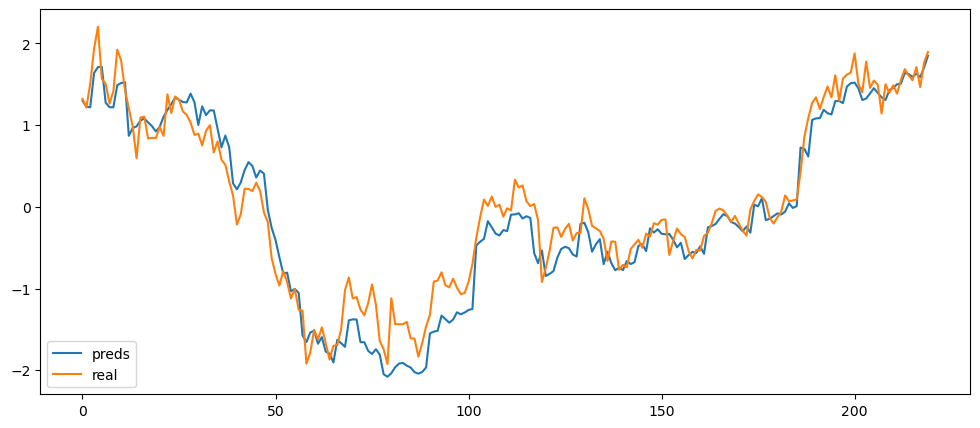

In [24]:
######## 실행5
# 모델 성능평가하기
import matplotlib.pyplot as plt

model.eval()
loader = DataLoader(dataset, batch_size=1)
preds = []
total_loss = 0
with torch.no_grad() :
    model.load_state_dict(torch.load('rnn_TSLA.pth', map_location=device, weights_only=False))
    for data, label in loader:
        # 초기 은닉상태의 배치크기는 DataLoader가 주는 배치 크기
        batch_size = data.size(0)
        ho = torch.zeros(5,batch_size,8).to(device)
        # 모델의 예측값
        pred = model(data.to(device), ho)
        preds.append(pred.item())
        # 손실값
        loss = nn.MSELoss()(pred, label.to(device))
        total_loss += (loss.item() / len(loader))

print (f'total_loss : {total_loss: .4f}')

plt.figure(figsize=(12,5))
plt.plot(preds, label='preds')
plt.plot(dataset.label[30:], label='real')
plt.legend()
plt.show()
